<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Image_Classification_Aula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
from torchvision import datasets
import torch
data_folder = '~/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

In [42]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [43]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

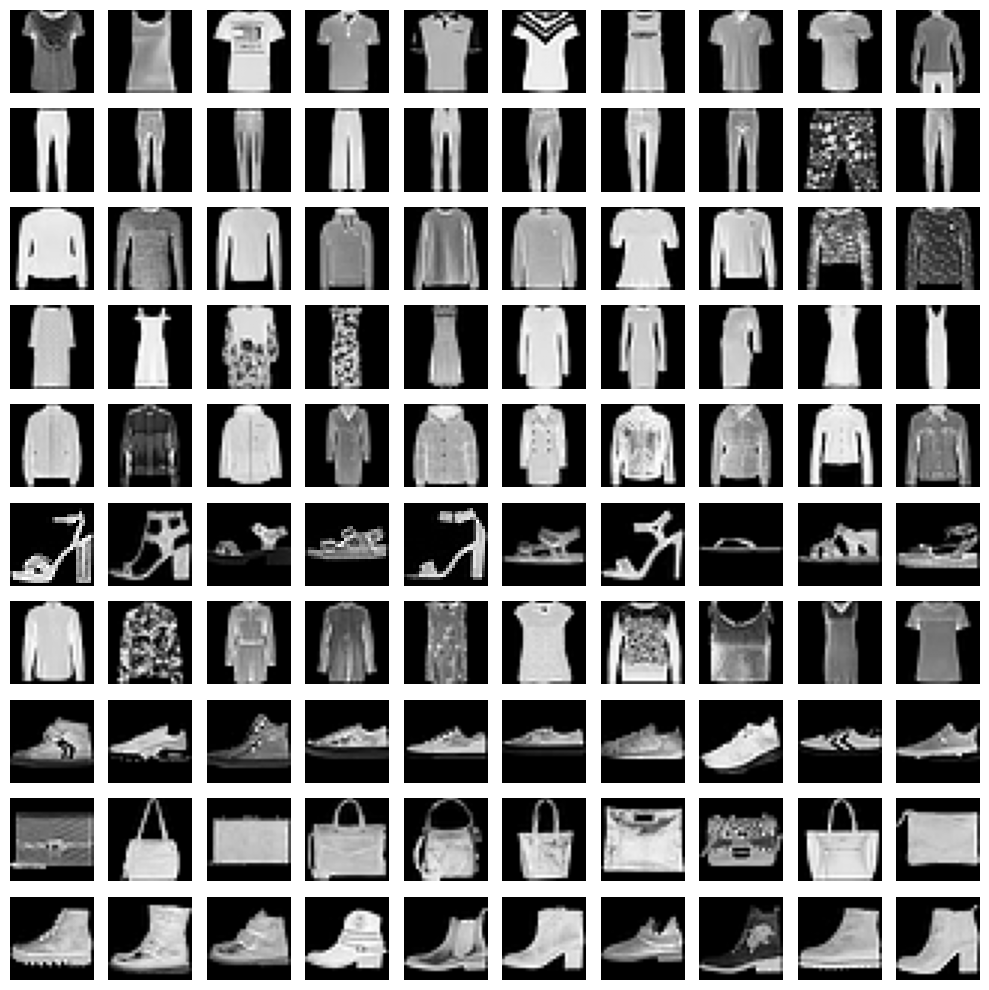

In [44]:
R, C = len(tr_targets.unique()), 10
fig, ax = plt.subplots(R,C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
  label_x_rows = np.where(tr_targets == label_class)[0]
  for plot_cell in plot_row:
    plot_cell.grid(False); plot_cell.axis('off')
    ix = np.random.choice(label_x_rows)
    x,y = tr_images[ix], tr_targets[ix]
    plot_cell.imshow(x, cmap='gray')
plt.tight_layout()

In [45]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
from torchvision import datasets

In [46]:
class FMNISTDataset(Dataset):
  def __init__(self,x,y):
    x = x.float()
    x = x.view(-1,28*28)
    self.x, self.y = x,y
  def __getitem__(self, idx):
    x,y = self.x[idx], self.y[idx]
    return x.to(device), y.to(device)
  def __len__(self):
    return len(self.x)

In [47]:
def get_data():
  train = FMNISTDataset(tr_images, tr_targets)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True)
  return trn_dl


In [48]:
from torch.optim import SGD
def get_model():
    # cria uma rede sequencial
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2) # otimizador

    return model, loss_fn, optimizer


In [49]:
# decorador que desativa
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

In [50]:
# define a função responsavel por treinar
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

In [51]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model() # cria o modelo

In [52]:
# inicializa listas para armazenar
losses, accuracies = [], []
# loop principal
for epoch in range(5):
    print(epoch)
    epoch_losses, epoch_accuracies = [], []
    # percorre todos os lotes
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        epoch_losses.append(batch_loss)
    epoch_loss = np.array(epoch_losses).mean()
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        epoch_accuracies.extend(is_correct)
    epoch_accuracy = np.mean(epoch_accuracies)
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)

0
1
2
3
4


/tmp/ipykernel_2727/2845351029.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


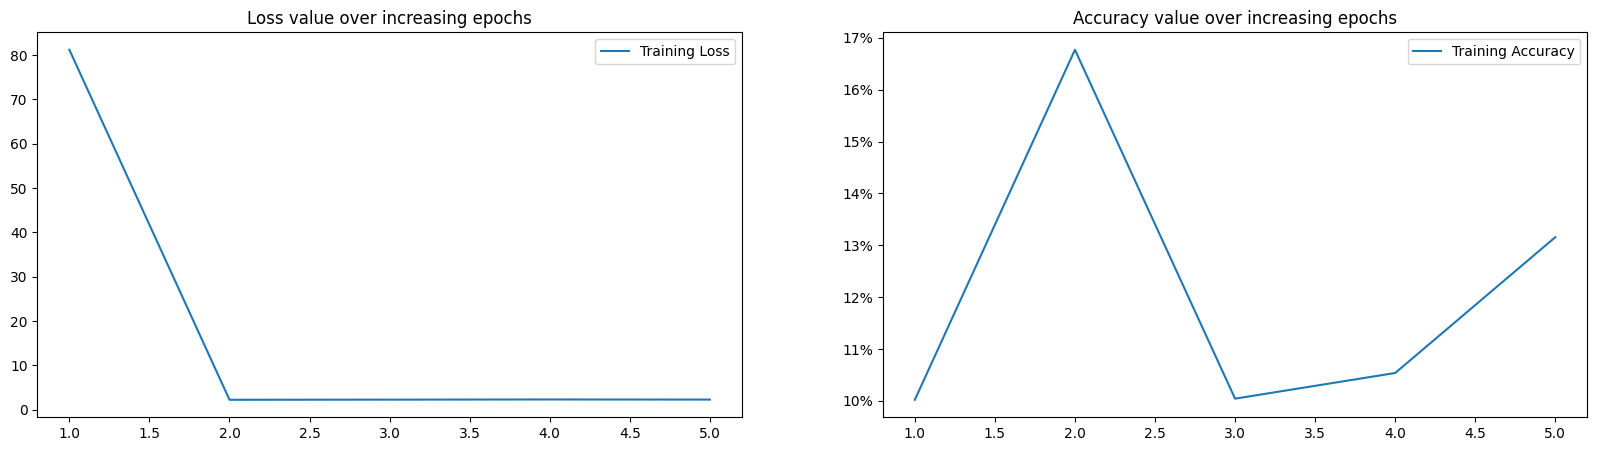

In [53]:
# cria um array de 1 a 5
epochs = np.arange(5) + 1
plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
# formata o eixo Y para exibir valores
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()
